In [1]:
import tensorflow as tf
import glob
import numpy as np
import pandas as pd
import math
import time
import sys
import statistics 
from tqdm import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
tf.config.run_functions_eagerly(True)

#Run with or without tensorflow_probability

"""
TODO:
Could select only real data with events. Done
Import my save.txt routine to optionally write output.
Rename the To TC with rate constants K13 K12 K23 etc.
Would another state help? I don't think so... 4 states should capture realistic bursting.
Could draw the transition matrix as a graph too? Too fancy. User can do this.
Noise could be more authentic still. 
a. Some slow-wave. freq, phase, amp.
b. Some open channel noise. tf.boolean_mask ...if open add white noise? could be slow.
c. replace noise with Sam noise? was it all TF?
d. SPIKE GENERATION SHOULD BE CHANGED, max should be x not abs(x) and number should be abs(x) not be abs(x) +1. X
e. pink noise should also be tf.function decorated!! X
f. WE ARE USING PROBABILITIES NOT RATES SO NEED TO ADAPT OR CORRECT BEFORE WRITING TO FILE!

F:: concerned about whether I have consistent use of dt.  In some places it seems with have an array that is sequence_length long. In other places this is called 
size and sometimes steps are 1 long and others they are df long @@
OK ...looks like the only time dt is used is when plotting simulated output.

CHANNEL IS LANE 0
RAW IS LANE 1

RUNNING ON MBP metal_101 env (102 doesn't work!). TF version 2.16 I believe. 
pip install tensorflow-macos tensorflow-metal
NB:
This version irrationally markovian simulates two channels but only ever uses the first 

"""
import os
import logging

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # '0' = all logs, '1' = filter out INFO logs, '2' = filter out WARNING logs, '3' = filter out ERROR logs

# Suppress other warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Additional suppression for TensorFlow 2.x
tf.get_logger().setLevel('ERROR')

"""claude suggested this can improve performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')"""

# List all physical GPUs
gpus = tf.config.list_physical_devices('GPU')
#tf.config.optimizer.set_jit(True)
#tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"Number of GPUs detected: {len(gpus)}")


2025-06-30 17:11:08.475444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-30 17:11:08.512882: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-30 17:11:08.523541: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-30 17:11:08.547137: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-30 17:11:09.695384: W tensorflow/comp

Number of GPUs detected: 1


I0000 00:00:1751299871.697759   25288 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:15:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1751299871.729119   25288 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:15:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1751299871.729307   25288 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:15:00.0/numa_node
Your kernel may have been built without NUMA support.


In [20]:
n = 1  # Number of channels
dt = tf.constant(0.1, dtype=tf.float32)

#Must be a multiple of 2!!!
#Size of channel (relative to the channels so one channel
#ESTIMATED
OFFSET=0.5
SCALE=1
FC=3
size=1000
sequence_length = size #this is a fix as I update the entire code. Try to always use "sequence_len"
batch_size=50
buffer=100 #in from each edge
context_win=50
attention_start = 20
attention_min = 2
crop=sequence_length-buffer

NOISEUP = False
DROPSILENCE = True

In [21]:
def create_dataset(fake_data, batch_size):
    # Calculate number of complete batches
    n_samples = len(fake_data)
    n_batches = n_samples // batch_size
    
    # Trim data to be evenly divisible by batch_size
    trimmed_size = n_batches * batch_size
    trimmed_data = fake_data[:trimmed_size]
    
    # Create dataset with proper shuffling and repeat
    dataset = tf.data.Dataset.from_tensor_slices(trimmed_data)
    dataset = dataset.shuffle(buffer_size=len(trimmed_data))
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.repeat()  # Add repeat() here
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


In [22]:
def throw_unchanged(training_data, max_unchanged=10):
    """
    max_unchanged = percentage that have no events that will be allowed
    """
    # Get first column
    first_column = training_data[:, :, 0]
    
    # Calculate if each sequence is unchanged
    mins = tf.reduce_min(first_column, axis=1)
    maxs = tf.reduce_max(first_column, axis=1)
    all_same = tf.abs(maxs - mins) < 1e-3  # or appropriate threshold
    
    # Convert to numpy for easier handling
    all_same_np = all_same.numpy()
    total_records = len(training_data)
    unchanged_count = np.sum(all_same_np)
    unchanged_percent = (unchanged_count / total_records) * 100
    print(f"Initial unchanged count: {unchanged_count} out of {total_records}")
    changed = total_records - unchanged_count
    print(f"Initial percentage unchanged: {unchanged_percent:.1f}%")
    
    if unchanged_percent > max_unchanged:
        # Calculate how many unchanged to keep
        print("changed",changed)
        print("(max_unchanged/100)", (max_unchanged/100))
        keep_count = round(changed * (max_unchanged/100))
        print(f"\nKeeping {keep_count} unchanged sequences")
        
        # Get indices of changed and unchanged records
        changed_indices = np.where(~all_same_np)[0]    # All changing sequences
        unchanged_indices = np.where(all_same_np)[0]   # All unchanged sequences
        
        # Randomly select from unchanged
        keep_unchanged_indices = np.random.choice(unchanged_indices, keep_count, replace=False)
        
        # Combine both sets of indices
        keep_indices = np.concatenate([changed_indices, keep_unchanged_indices])
        
        # Sort indices to maintain original order
        keep_indices = np.sort(keep_indices)
        
        # Apply the indices to filter the data
        training_data = tf.gather(training_data, keep_indices)
        
        # Verify final percentages
        final_mins = tf.reduce_min(training_data[:, :, 0], axis=1)
        final_maxs = tf.reduce_max(training_data[:, :, 0], axis=1)
        final_unchanged = tf.equal(final_mins, final_maxs).numpy()
        final_unchanged_percent = (np.sum(final_unchanged) / len(training_data)) * 100
        print(f"\nFinal unchanged count: {np.sum(final_unchanged)} out of {len(training_data)}")
        print(f"Final percentage unchanged: {final_unchanged_percent:.1f}%")
    
    print(f"\nFinal dataset size: {tf.shape(training_data)[0]}")
    return training_data

In [23]:
import numpy as np
from scipy.interpolate import interp1d

def generate_perlin_noise_1d(length, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Generate 1D Perlin noise with multiple octaves
    
    Args:
        length: Length of output array
        octaves: Number of octaves for fBm
        persistence: Amplitude decrease factor per octave
        lacunarity: Frequency increase factor per octave
    """
    noise = np.zeros(length)
    max_amplitude = 0
    
    for i in range(octaves):
        # Generate base random values
        period = max(2, int(length // (lacunarity ** i)))  # Fix: Convert to int and ensure minimum of 2
        
        # Create random gradients
        gradients = np.random.randn(period + 1)
        
        # Create regular points for interpolation
        x_vals = np.linspace(0, period, period + 1)
        distances = np.linspace(0, period, length)
        
        # Interpolate between gradients
        interp = interp1d(x_vals, gradients, kind='cubic')
        amplitude = persistence ** i
        noise += interp(distances) * amplitude
        max_amplitude += amplitude
        
    # Normalize
    return noise / max_amplitude

def generate_fbm_noise(length, hurst=0.7, octaves=4):
    """
    Generate fractional Brownian motion noise
    
    Args:
        length: Length of output array
        hurst: Hurst parameter (0.5 for regular Brownian motion, >0.5 for persistent)
        octaves: Number of octaves to sum
    """
    noise = np.zeros(length)
    frequencies = np.fft.fftfreq(length)
    frequencies[0] = 1e-6  # Avoid division by zero
    
    # Generate spectrum following power law
    amplitudes = np.abs(frequencies) ** (-2 * hurst - 1)
    phases = 2 * np.pi * np.random.rand(length)
    
    # Create complex spectrum
    spectrum = amplitudes * (np.cos(phases) + 1j * np.sin(phases))
    
    # Inverse FFT to get time series
    noise = np.fft.ifft(spectrum).real
    return (noise - noise.mean()) / noise.std()

def augment_tensor_with_sophisticated_noise(data, n_copies, base_noise_std=1e-6, 
                                         hurst=0.7, octaves=4, perlin_weight=0.3):
    """
    Create n copies of input tensor and add sophisticated noise combining fBm and Perlin noise
    
    Args:
        data: Input tensor of shape (x, 1000, 2)
        n_copies: Number of copies to create
        base_noise_std: Base standard deviation for noise scaling
        hurst: Hurst parameter for fBm (0.5-0.9, higher = more persistent)
        octaves: Number of octaves for both noise types
        perlin_weight: Weight of Perlin noise vs fBm (0-1)
    
    Returns:
        Augmented tensor of shape (n*x, 1000, 2)
    """
    x, time_steps, channels = data.shape
    augmented = np.tile(data, (n_copies, 1, 1))
    
    # Generate noise for each copy
    for i in range(n_copies * x):
        # Generate both types of noise
        fbm = generate_fbm_noise(time_steps, hurst, octaves)
        perlin = generate_perlin_noise_1d(time_steps, octaves)
        
        # Combine noises
        combined_noise = (perlin_weight * perlin + 
                        (1 - perlin_weight) * fbm)
        
        # Normalize and scale
        combined_noise = (combined_noise - combined_noise.mean()) / combined_noise.std()
        combined_noise *= base_noise_std
        
        # Add to second channel only
        augmented[i, :, 1] += combined_noise
    
    return augmented

In [24]:
#Create REAL Trainging Data
# Load all parquet files from directory
file_paths = glob.glob("2024_06_17/combo/*.parquet") 
dfs = []

for file_path in file_paths:
    print(file_path)
    temp_df = pd.read_parquet(file_path)
    temp_df = temp_df[["Channels","Noisy Current"]]
    temp_df = temp_df-temp_df.round().mode().iloc[0]
    dx= temp_df['Noisy Current'].max() - temp_df['Noisy Current'].min()
    if temp_df["Channels"].max() > 0:
        sx = np.round(dx/temp_df["Channels"].max(),2)
    else:
        #leave it out if there are no events.
        print("No channels so skipping")
        next
    #Turns out some channges way bigger than others
    print(f"Channels = {temp_df['Channels'].max()}, min = {np.round(temp_df['Noisy Current'].min(),2)};  max = {np.round(temp_df['Noisy Current'].max(),2)}; size = {sx}") 
    if sx < 32:    
        dfs.append(temp_df)
    
# Concatenate all files
df = pd.concat(dfs, ignore_index=True)
max_channels = df["Channels"].max()
print("Max channels:", max_channels)

# optionally add more noise
# Sean files huge. Decimate them
df = df[::10]
NOISE = True

# Convert to tensor and reshape BEFORE scaling
data_array = df.to_numpy()
data_array = tf.convert_to_tensor(data_array, dtype=tf.float32)
print("reshaping")
excess = len(data_array) % sequence_length
if excess != 0:
    padding_needed = sequence_length - excess
    data_array = tf.concat([data_array, data_array[:padding_needed]], axis=0)

training_data = tf.reshape(data_array, [-1, sequence_length, 2])

# Filter unchanged records BEFORE scaling
if DROPSILENCE:
    print("\nBefore throwing",training_data.shape)
    print("Throwing away unchanged")
    training_data = throw_unchanged(training_data, max_unchanged=0)
    print("\nAfter throwing:",training_data.shape)

# NOW apply MinMax scaling after filtering
print("\nStand by - we're minMax scaling the lot")
# Reshape back to 2D for scaler
training_data_2d = tf.reshape(training_data, [-1, 2])
training_data_np = training_data_2d.numpy()

# ch0 will contain all values from the first column (feature 0)
ch0_data = training_data_np[:, 0].reshape(-1, 1) # Reshape to (N, 1) for the scaler
# ch1 will contain all values from the second column (feature 1)
ch1_data = training_data_np[:, 1].reshape(-1, 1) # Reshape to (N, 1) for the scaler

# Create and fit a scaler for the first channel with its desired range
scaler_ch0 = MinMaxScaler(feature_range=(0, 1))
scaled_ch0 = scaler_ch0.fit_transform(ch0_data)

# Create and fit a scaler for the second channel with its desired range
scaler_ch1 = MinMaxScaler(feature_range=(-1, 1)) # This range is just an example; set it as needed
scaled_ch1 = scaler_ch1.fit_transform(ch1_data)
scaled_ch0 = scaled_ch0.reshape(-1, sequence_length)
scaled_ch1 = scaled_ch1.reshape(-1, sequence_length)
training_data = tf.stack([scaled_ch0, scaled_ch1], axis=-1)


print("\nFinal Size before augmentation:",training_data.shape)

# Apply augmentation last
if NOISEUP:
    training_data = augment_tensor_with_sophisticated_noise(training_data, n_copies=25, base_noise_std=1e-4, 
                                         hurst=0.7, octaves=4, perlin_weight=0.3)
    print("\nFinal Augmented Size:",training_data.shape)


2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_5.parquet
Channels = 2.0, min = -5.46;  max = 28.26; size = 16.86
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_10.parquet
Channels = 1.0, min = -8.8;  max = 52.34; size = 61.14
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_34.parquet
Channels = 1.0, min = -8.83;  max = 61.53; size = 70.36
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_49.parquet
Channels = 1.0, min = -10.21;  max = 50.37; size = 60.58
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_28.parquet
Channels = 1.0, min = -7.5;  max = 50.82; size = 58.32
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_50.parquet
Channels = 1.0, min = -8.75;  max = 53.4; size = 62.15
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_11.parquet
Channels = 2.0, min = -7.53;  max = 83.9; size = 45.72
2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_27.parquet
Channels = 2.0, min = -2.17;  max = 27.52; size = 14.85
2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_

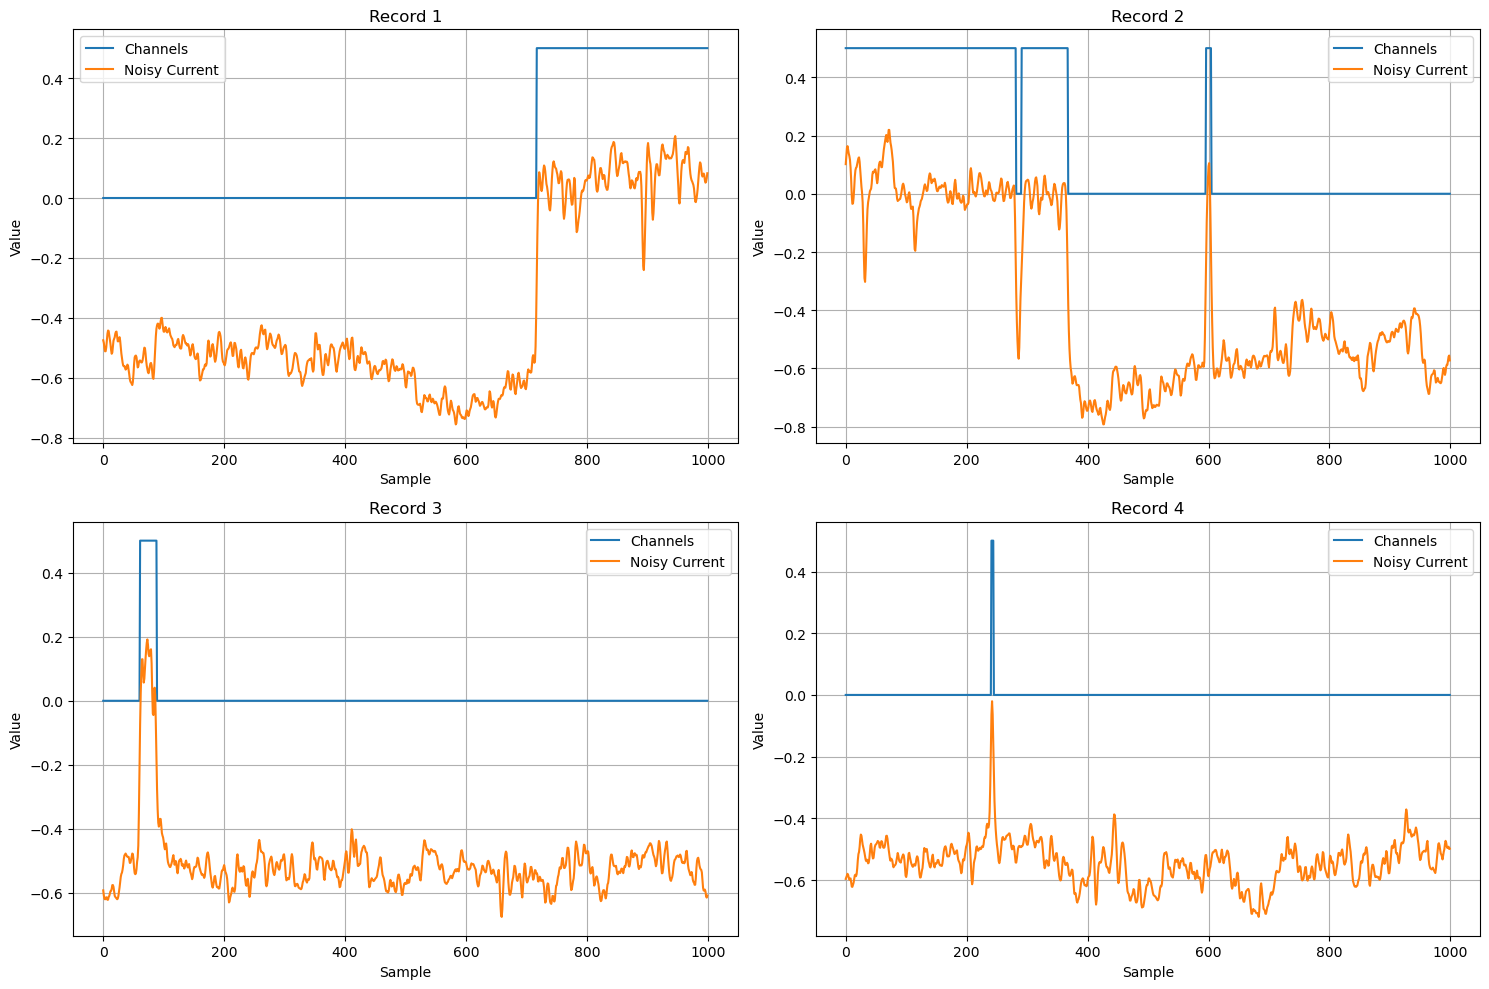


Record 1:
Channel range: 0.00 to 0.50
Raw signal range: -0.76 to 0.21

Record 2:
Channel range: 0.00 to 0.50
Raw signal range: -0.79 to 0.22

Record 3:
Channel range: 0.00 to 0.50
Raw signal range: -0.67 to 0.19

Record 4:
Channel range: 0.00 to 0.50
Raw signal range: -0.72 to -0.02


In [25]:
import matplotlib.pyplot as plt

def plot_n_records(data, n):
    # Calculate grid dimensions
    rows = int(np.ceil(n/2))
    cols = min(2, n)  # Use 2 columns unless n=1
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if n == 1:
        axes = np.array([axes])  # Make single axis iterable
    axes = axes.ravel()  # Flatten the array for easier indexing

    for i in range(n):
        axes[i].plot(data[i, :, 0], label='Channels')
        axes[i].plot(data[i, :, 1], label='Noisy Current')
        axes[i].set_title(f'Record {i+1}')
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_xlabel('Sample')
        axes[i].set_ylabel('Value')
    
    # Turn off any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print stats for each record
    for i in range(n):
        print(f"\nRecord {i+1}:")
        print(f"Channel range: {tf.reduce_min(data[i, :, 0]):.2f} to {tf.reduce_max(data[i, :, 0]):.2f}")
        print(f"Raw signal range: {tf.reduce_min(data[i, :, 1]):.2f} to {tf.reduce_max(data[i, :, 1]):.2f}")

# Now you can call it with any number
n = 4  # Change this to however many you want to see
plot_n_records(training_data, n)

In [26]:
class ScaleLayer(tf.keras.layers.Layer):
    def __init__(self, initial_value=1, **kwargs):
        super().__init__(**kwargs)  # Pass kwargs to parent
        self.initial_value = initial_value
    
    def build(self, input_shape):
        self.scale = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_value),
            trainable=True,
            name='scale_factor'
        )
    
    def call(self, inputs, training=None):
        return inputs * self.scale

#scaling differely for different batches
class ScaleLayer(tf.keras.layers.Layer):
    def __init__(self, initial_value=1, noise_std=0.1, **kwargs):
        super().__init__(**kwargs)
        self.initial_value = initial_value
        self.initial_noise_std = noise_std  # Store initial value
    
    def build(self, input_shape):
        self.scale = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_value),
            trainable=True,
            name='scale_factor'
        )
        self.noise_std = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_noise_std),
            trainable=True,
            name='scale_std'
        )
    
    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        random_scales = tf.random.normal([batch_size, 1, 1], mean=1.0, stddev=self.noise_std)
        return inputs * self.scale * random_scales

class OffsetLayer(tf.keras.layers.Layer):
    def __init__(self, initial_value=0.0, **kwargs):
        super().__init__(**kwargs)  # Pass kwargs to parent
        self.initial_value = initial_value
    
    def build(self, input_shape):
        self.offset = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_value),
            trainable=True,
            name='offset_factor'
        )
    
    def call(self, inputs, training=None):
        return inputs + self.offset

class LowpassLayer(tf.keras.layers.Layer):
    def __init__(self, kernel_size, cutoff_freq, method='gaussian', fs=1.0, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.cutoff_freq = cutoff_freq
        self.method = method
        self.fs = fs
    
    def build(self, input_shape):
        # Initialize weights using your existing logic
        if self.method == 'gaussian':
            sigma = 1.0 / (2 * np.pi * self.cutoff_freq)
            x = np.linspace(-(self.kernel_size//2), self.kernel_size//2, self.kernel_size)
            weights = np.exp(-0.5 * (x/sigma)**2)
        elif self.method == 'moving_avg':
            weights = np.ones(self.kernel_size)
        elif self.method == 'hamming':
            weights = np.hamming(self.kernel_size)
        elif self.method == 'fir':
            nyquist = self.fs / 2.0
            normalized_cutoff = self.cutoff_freq / nyquist
            weights = signal.firwin(self.kernel_size, normalized_cutoff, window='hamming')
        else:
            raise ValueError(f"Unknown method: {self.method}")
        
        # Normalize
        weights = weights / np.sum(weights)
        
        # Properly reshape for conv1d: (kernel_size, input_channels, output_channels)
        num_channels = input_shape[-1]
        weights = np.tile(weights.reshape(-1, 1, 1), (1, num_channels, num_channels))
        
        # Create trainable weight
        self.kernel = self.add_weight(
            shape=(self.kernel_size, num_channels, num_channels),
            initializer=tf.keras.initializers.Constant(weights),
            trainable=True,
            name='lowpass_kernel'
        )
    
    def call(self, inputs):
        return tf.nn.conv1d(inputs, self.kernel, stride=1, padding='SAME')

def get_filter_cutoff(layer, fs=1.0):
    kernel = layer.kernel.numpy()
    # Get the filter weights for the first channel
    weights = kernel[:, 0, 0]
    
    # Compute frequency response
    freqs = np.linspace(0, fs/2, 1024)
    freq_response = np.fft.fft(weights, n=2048)[:1024]
    magnitude = np.abs(freq_response)
    
    peak_mag = np.max(magnitude)
    cutoff_indices = np.where(magnitude <= 0.707 * peak_mag)[0]
    
    # Handle case where no cutoff is found
    if len(cutoff_indices) == 0:
        # Return the frequency where magnitude is closest to 0.707 * peak_mag
        closest_idx = np.argmin(np.abs(magnitude - 0.707 * peak_mag))
        return freqs[closest_idx]
    else:
        return freqs[cutoff_indices[0]]

class RandomWalkBaseline(tf.keras.layers.Layer):
    def __init__(self, initial_amplitude=0.1, initial_step_size=0.1, smooth_window=50, **kwargs):
        super().__init__(**kwargs)
        self.initial_amplitude = initial_amplitude
        self.initial_step_size = initial_step_size
        self.smooth_window = smooth_window
    
    def build(self, input_shape):
        # Amplitude of wobble
        self.amplitude = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_amplitude),
            trainable=True,
            name='wobble_amplitude',
            constraint=tf.keras.constraints.NonNeg()  # This is fine for scalars
        )
        
        # Step size (frequency content)
        self.step_size = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_step_size),
            trainable=True,
            name='wobble_step_size',
            constraint=tf.keras.constraints.NonNeg()  # This is fine for scalars
        )
        
        # Smoothness factor - NO MinMaxNorm!
        self.smooth_scale = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name='wobble_smoothness'
            # Remove the MinMaxNorm constraint
        )
    
    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        seq_length = tf.shape(inputs)[1]
        
        # Generate random steps with learned step size
        steps = tf.random.normal([batch_size, seq_length], stddev=self.step_size)
        
        # Cumulative sum to create random walk
        walk = tf.cumsum(steps, axis=1)
        
        # Normalize to prevent explosion
        walk = walk - tf.reduce_mean(walk, axis=1, keepdims=True)
        walk = walk / (tf.math.reduce_std(walk, axis=1, keepdims=True) + 1e-8)
        
        # Use FIXED window size for avg_pool1d
        walk = tf.reshape(walk, [batch_size, seq_length, 1])
        walk = tf.nn.avg_pool1d(walk, self.smooth_window, 1, 'SAME')
        
        # Apply learnable smoothness as a scaling factor
        # Manually clip the smooth_scale value
        smooth_scale_clipped = tf.clip_by_value(self.smooth_scale, 0.1, 3.0)
        walk = walk * smooth_scale_clipped
        
        # Scale by learned amplitude
        walk = walk * self.amplitude
        
        return inputs + walk

class TrainableGaussianNoise(tf.keras.layers.Layer):
    def __init__(self, initial_stddev=0.01, **kwargs):
        super().__init__(**kwargs)
        self.initial_stddev = initial_stddev
    
    def build(self, input_shape):
        self.stddev = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_stddev),
            trainable=True,
            name='noise_stddev',
            constraint=tf.keras.constraints.NonNeg()  # Keep positive
        )
    
    def call(self, inputs, training=None):
        noise = tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        return inputs + noise

class Trainable1fNoise(tf.keras.layers.Layer):
    def __init__(self, initial_stddev=0.01, initial_slope=1.0, **kwargs):
        super().__init__(**kwargs)
        self.initial_stddev = initial_stddev
        self.initial_slope = initial_slope
    
    def build(self, input_shape):
        self.stddev = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_stddev),
            trainable=True,
            name='noise_stddev',
            constraint=tf.keras.constraints.NonNeg()
        )
        
        self.slope = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.initial_slope),
            trainable=True,
            name='frequency_slope',
            constraint=tf.keras.constraints.NonNeg()
        )
    
    def call(self, inputs, training=None):
        # Generate white noise with same shape as inputs
        white_noise = tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        
        # Apply FFT along sequence dimension (axis=1)
        fft_noise = tf.signal.fft(tf.cast(white_noise[:,:,0], tf.complex64))
        
        # Create 1/f frequency response
        seq_len = tf.shape(inputs)[1]
        freqs = tf.range(1, seq_len//2 + 1, dtype=tf.float32)
        freqs = tf.concat([tf.ones([1]), freqs], axis=0)
        
        # Create full frequency response (mirrored for real signal)
        freq_response = tf.pow(freqs, -self.slope/2.0)
        freq_response = tf.concat([freq_response, freq_response[-2:0:-1]], axis=0)
        
        # Apply shaping and convert back
        shaped_fft = fft_noise * tf.cast(freq_response[None, :], tf.complex64)
        colored_noise = tf.math.real(tf.signal.ifft(shaped_fft))
        
        # Reshape back to original shape
        colored_noise = colored_noise[:, :, None]
        
        return inputs + colored_noise

class TrainableHighFreqNoise(tf.keras.layers.Layer):
    def __init__(self, initial_stddev=0.15, **kwargs):
        super().__init__(**kwargs)
        self.initial_stddev = initial_stddev
    
    def build(self, input_shape):
        self.stddev = self.add_weight(
            shape=(), 
            initializer=tf.keras.initializers.Constant(self.initial_stddev), 
            trainable=True, 
            name='noise_stddev', 
            constraint=tf.keras.constraints.NonNeg()
        )
        
        # Fix: Create proper 3D kernel shape
        kernel_init = tf.constant([[[-1.]], [[2.]], [[-1.]]], dtype=tf.float32)
        self.filter_kernel = self.add_weight(
            shape=(3, 1, 1), 
            initializer=tf.keras.initializers.Constant(kernel_init), 
            trainable=True, 
            name='highpass_kernel'
        )
    
    def call(self, inputs, training=None):
        noise = tf.random.normal(tf.shape(inputs), stddev=self.stddev)
        filtered_noise = tf.nn.conv1d(noise, self.filter_kernel, stride=1, padding='SAME')
        return inputs + filtered_noise


class IonChannelBaselineAwareAttention(tf.keras.layers.Layer):
    def __init__(self, transition_amplification=50, context_window=20, **kwargs):
        super().__init__(**kwargs)
        self.transition_amplification = transition_amplification
        self.context_window = context_window
        
    def build(self, input_shape):
        self.transition_weight = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(self.transition_amplification),
            trainable=True,
            name='transition_attention_weight'
        )
        
    def call(self, inputs, training=None):
        # Split channels
        clean_channel = inputs[:, :, 0:1]
        noisy_channel = inputs[:, :, 1:2]
        
        # Detect transitions (changes between time points)
        diff = clean_channel[:, 1:, :] - clean_channel[:, :-1, :]
        diff = tf.concat([tf.zeros_like(clean_channel[:, :1, :]), diff], axis=1)
        is_transition = tf.abs(diff) > 0.01
        
        # Expand transitions to include context window
        is_transition_expanded = self.expand_attention_window(is_transition, self.context_window)
        
        # Apply constraint to keep weight meaningful
        transition_weight = tf.maximum(self.transition_weight, 10)
        
        # Create attention weights
        attention = tf.ones_like(clean_channel)
        attention = tf.where(is_transition_expanded, attention * transition_weight, attention)
        
        # Apply attention to both channels
        attended_clean = clean_channel #   * attention
        attended_noisy = noisy_channel * attention
        
        return tf.concat([attended_clean, attended_noisy], axis=-1)
    
    def expand_attention_window(self, mask, window_size):
        """Expand True regions by window_size points on each side."""
        mask_float = tf.cast(mask, tf.float32)
        kernel_size = 2 * window_size + 1
        kernel = tf.ones([kernel_size, 1, 1], dtype=tf.float32)
        
        expanded = tf.nn.conv1d(
            mask_float, 
            kernel, 
            stride=1, 
            padding='SAME'
        )
        
        return expanded > 0.0


In [27]:
# Define the discriminator model batch, record len, channels = events then noise

def make_discriminator_model():
    input_shape = (sequence_length,2) 
    inputs = tf.keras.Input(shape=input_shape)

    x = IonChannelBaselineAwareAttention()(inputs)

    # Reshape input to add channel dimension
    x = tf.keras.layers.Reshape((sequence_length, 2))(x)
    
    # 1D Convolutional layers
    x = tf.keras.layers.Conv1D(8, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Conv1D(16, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Conv1D(32, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Dropout(0.3) (x)
    
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(1)(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

def make_generator_model():
    input_layer = tf.keras.layers.Input(shape=(sequence_length, 1))
    # Scale with learnable parameter (1 param)
    scaled_signal = ScaleLayer(SCALE, name='signal_scale')(input_layer)
    wobbled_input = RandomWalkBaseline(initial_amplitude=0.1)(scaled_signal)
    
    # Generate PURE noise components by passing zeros  
    zeros = tf.keras.layers.Lambda(lambda x: tf.zeros_like(x))(scaled_signal)
    white_noise_layer = TrainableGaussianNoise(0.01, name='white_noise')(zeros)
    white_noise = white_noise_layer  # Already pure noise since zeros + noise = noise
    
    low_noise_layer = TrainableGaussianNoise(0.05, name='low_freq_noise')(zeros)
    low_noise = tf.keras.layers.AveragePooling1D(pool_size=10, strides=1, padding='same')(low_noise_layer)
    
    pink_noise = Trainable1fNoise(0.05, initial_slope=0.1, name='pink_noise')(zeros)
    high_freq_noise = TrainableHighFreqNoise(0.15, name='high_freq_noise')(zeros)

    # Now add the scaled signal once plus all pure noise components
    physics_based = tf.keras.layers.Add()([white_noise,
                                          low_noise, 
                                          pink_noise,
                                          high_freq_noise])
    
    # Apply offset to the final result
    physics_based = OffsetLayer(OFFSET, name='signal_offset')(physics_based)
    
    # Rest remains the same...
    learned_features = tf.keras.layers.Conv1D(4, 7, padding='same', activation='tanh', use_bias=False)(physics_based)
    learned_features = tf.keras.layers.Conv1D(1, 1, padding='same', use_bias=False)(learned_features)
    
    noise_mod = tf.keras.layers.Conv1D(1, 5, padding='same', activation='tanh', use_bias=False)(learned_features)
    #state_noise = TrainableGaussianNoise(0.05, name='state_noise')(scaled_signal)
    #state_noise = tf.keras.layers.Multiply()([state_noise - physics_based, noise_mod])
    
    combined = tf.keras.layers.Add()([physics_based, learned_features, noise_mod, wobbled_input])
    output = LowpassLayer(kernel_size=15, cutoff_freq=FC, method='gaussian', name='lowpass_filter')(combined)
    
    return tf.keras.Model(inputs=input_layer, outputs=output)

#Loss functions and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


#Try balancing loss to one channel or other
@tf.function(experimental_compile=True)
def discriminator_loss(real_output, fake_output):
    #Compute standard binary cross-entropy loss
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    
    #Apply channel-wise weighting
    #Assuming shape: [batch_size, 1024, 2]
    weights = tf.constant([0.99, 0.01], dtype=real_loss.dtype)
    weights = tf.reshape(weights, [1, 1, 2])  # Broadcastable shape
    
    real_loss_weighted = real_loss * weights
    fake_loss_weighted = fake_loss * weights
    
    #Reduce over the last dimension (channels), then average over batch and sequence
    real_loss_final = tf.reduce_mean(tf.reduce_sum(real_loss_weighted, axis=-1))
    fake_loss_final = tf.reduce_mean(tf.reduce_sum(fake_loss_weighted, axis=-1))
    
    return real_loss_final + fake_loss_final

@tf.function(experimental_compile=True)
def generator_loss(fake_output):
    base_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
        tf.ones_like(fake_output), fake_output, from_logits=True))

    # Add L2 regularization on noise parameters
    reg_loss = 0.0
    for layer in generator.layers:
        # Add TrainableHighFreqNoise to the list of regularized layers
        if isinstance(layer, (TrainableGaussianNoise, RandomWalkBaseline, TrainableHighFreqNoise)):
            for weight in layer.trainable_weights:
                # You might want to apply different strengths, but starting
                # with the same is fine.
                reg_loss += 0.01 * tf.nn.l2_loss(weight)

    return base_loss + reg_loss

generator = make_generator_model()
generator.summary()
discriminator = make_discriminator_model()
discriminator.summary()
generator_optimizer = tf.keras.optimizers.Adam(1e-5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-5)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ signal_scale        │ (None, 1000, 1)   │          2 │ input_layer_2[0]… │
│ (ScaleLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1000, 1)   │          0 │ signal_scale[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ low_freq_noise      │ (None, 1000, 1)   │          1 │ lambda_1[0][0]    │
│ (TrainableGaussian… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ white_noise         │ (None, 1000, 1)   │          1 │ lambda_1[0][0]    │
│ (TrainableGaussian… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 1000, 1)   │          0 │ low_freq_noise[0… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pink_noise          │ (None, 1000, 1)   │          2 │ lambda_1[0][0]    │
│ (Trainable1fNoise)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ high_freq_noise     │ (None, 1000, 1)   │          4 │ lambda_1[0][0]    │
│ (TrainableHighFreq… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1000, 1)   │          0 │ white_noise[0][0… │
│                     │                   │            │ average_pooling1… │
│                     │                   │            │ pink_noise[0][0], │
│                     │                   │            │ high_freq_noise[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ signal_offset       │ (None, 1000, 1)   │          1 │ add_2[0][0]       │
│ (OffsetLayer)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1000, 4)   │         28 │ signal_offset[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 1000, 1)   │          4 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 1000, 1)   │          5 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_walk_baseli… │ (None, 1000, 1)   │          3 │ signal_scale[0][… │
│ (RandomWalkBaselin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1000, 1)   │          0 │ signal_offset[0]… │
│                     │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0],   │
│                     │                   │            │ random_walk_base… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lowpass_filter      │ (None, 1000, 1)   │         15 │ add_3[0][0]       │
│ (LowpassLayer)      │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 66 (264.00 B)

 Trainable params: 66 (264.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ion_channel_baseline_aware_att… │ (None, 1000, 2)        │             1 │
│ (IonChannelBaselineAwareAttent… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 500, 8)         │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 250, 16)        │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 125, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370 (13.16 KB)

 Trainable params: 3,370 (13.16 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training step
@tf.function(experimental_compile=True)
@tf.function  # Remove experimental_compile=True for now
def train_step(real_data):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate noise
        generated_noise = generator(real_data[:,:,0:1], training=True)
        
        # Check generator output is valid
        tf.debugging.assert_all_finite(generated_noise, "Generator produced NaN/Inf!")
        
        # Combine with original signal
        noised = tf.concat([real_data[:,:,0:1], generated_noise], axis=-1)

        # Get discriminator outputs
        real_output = discriminator(real_data, training=True)
        fake_output = discriminator(noised, training=True)

        # Calculate losses
        disc_loss = discriminator_loss(real_output, fake_output)       
        gen_loss = generator_loss(fake_output)
        
        # Check losses are valid
        tf.debugging.assert_all_finite(gen_loss, "Generator loss is NaN/Inf!")
        tf.debugging.assert_all_finite(disc_loss, "Discriminator loss is NaN/Inf!")

    # Get gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Clip gradients to prevent explosion
    gradients_of_generator, _ = tf.clip_by_global_norm(gradients_of_generator, 1.0)
    gradients_of_discriminator, _ = tf.clip_by_global_norm(gradients_of_discriminator, 1.0)

    # Apply gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # Always return a record (even if it might be problematic)
    index = tf.cast(tf.random.uniform([], 0, batch_size, dtype=tf.float32), tf.int32)
    record = noised[index,buffer:crop,:]
    
    return gen_loss, disc_loss, record
# Training loop
#@tf.function(experimental_compile=True)
def train(training_dataset,  epochs):
    for epoch in range(getREALepoch(), epochs, 1):
        steps_per_epoch = math.floor(training_data.shape[0] / batch_size)
        read_set_lr()
        
        # Initialize loss accumulators
        epoch_gen_loss = 0
        epoch_disc_loss = 0
        record = None  # Initialize record
        
        # Create iterators for both datasets
        training_iter = iter(training_dataset)

        for step in tqdm(range((steps_per_epoch)), total=steps_per_epoch, ncols=60):
            try:
                real_batch = next(training_iter)
                gen_loss, disc_loss, record = train_step(real_batch)
                epoch_gen_loss += gen_loss
                epoch_disc_loss += disc_loss
            except Exception as e:
                print(f"\n\nACTUAL ERROR IN TRAIN_STEP:")
                print(f"Error type: {type(e)}")
                print(f"Error message: {str(e)}")
                import traceback
                traceback.print_exc()
                raise e  # Re-raise to see full stack trace
        # Calculate average losses
        avg_gen_loss = epoch_gen_loss / tf.cast(steps_per_epoch, tf.float32)
        avg_disc_loss = epoch_disc_loss / tf.cast(steps_per_epoch, tf.float32)
        
        if (epoch + 1) % 1 == 0:
            clear_output(wait=True)
                        # --- Define the specific layers you want to monitor ---
            layers_to_monitor = [
                'signal_scale', 
                'signal_offset',
                'white_noise',
                'low_freq_noise',
                'pink_noise',
                'high_freq_noise',
                'state_noise'
            ]
        
            output_lines = [
                f"Epoch {epoch + 1}/{epochs} - Gen Loss: {avg_gen_loss:.4f}, Dis Loss: {avg_disc_loss:.4f}",
                "-------------------------------------",
                "Monitored Generator Weights:",
            ]
        
            for layer in generator.layers:
                # >>> The main change is here: check if the layer is in your list <<<
                if layer.name in layers_to_monitor:
                    if layer.trainable_weights:
                        weight_strings = []
                        for weight in layer.trainable_weights:
                            val = weight.numpy()
                            if val.ndim == 0:
                                weight_strings.append(f"{val:.4f}")
                            else:
                                weight_strings.append(str(np.round(val, 4)))
                        
                        output_lines.append(f"  - {layer.name}: [{', '.join(weight_strings)}]")
        
            tf.print("\n".join(output_lines), output_stream=sys.stdout)
                    

            checkpoint.save(file_prefix='noiseCheckpoints/checkpoint')
            #random_index1 = tf.random.uniform(shape=[], minval=0, maxval=tf.shape(training_data)[0], dtype=tf.int32)
            random_index2 = tf.random.uniform(shape=[], minval=0, maxval=tf.shape(training_data)[0], dtype=tf.int32)
            biPlotter([record, training_data[random_index2]], 0, random_index2, epoch)


In [29]:
def biPlotter(data, n, m, epoch):
    # Create a figure with two subplots (panels)
    fig, axs = plt.subplots(2, 1, figsize=(10, 6))
    axs[0].plot(data[0] )
    axs[0].set_title(f"Generated Wave, record {n}, epoch {epoch}")
    axs[0].set_ylim([min(np.min(data[0]), np.min(data[1])), max(np.max(data[0]), np.max(data[1]))])
    axs[1].plot(data[1][buffer:crop,:] )
    axs[1].set_title(f"Training Data, record {m}")
    axs[1].set_ylim([min(np.min(data[0]), np.min(data[1])), max(np.max(data[0]), np.max(data[1]))])
    plt.tight_layout()
    plt.savefig(f"chanFigs/fig{epoch}.png")
    plt.show()
    #time.sleep(1)

In [30]:
def writeMe(fake_dataset, samples=10000, dt=dt, epoch=0, file="noiseData/output.parquet", batch_size=100):
    all_outputs = []
    record_len = size 
    
    fake_iter = iter(fake_dataset)
    total_batches = samples // batch_size + (1 if samples % batch_size else 0)
    
    for batch_num in tqdm(range(total_batches)):
        try:
            fake_data_batch = next(fake_iter)
            current_batch_size = fake_data_batch.shape[0]
        except StopIteration:
            fake_iter = iter(fake_dataset)
            fake_data_batch = next(fake_iter)
            current_batch_size = fake_data_batch.shape[0]
        
        generated_noise = generator(fake_data_batch[:,:,0:1], training=False)
        noised = tf.concat([fake_data_batch[:,:,0:1], generated_noise], axis=-1)
        
        # Process each record in batch
        for record in range(current_batch_size):
            # First record - skip initial buffer too
            if len(all_outputs) == 0:
                output = noised[record, buffer:-buffer, :].numpy()  # Added buffer at start
                if output.shape[0] > 0:
                    all_outputs.append(output)
            else:
                # Find matching point
                target_val = int(all_outputs[-1][-1, 0])
                match_found = False
                
                for start_pos in range(buffer, record_len - buffer):
                    if int(noised[record, start_pos, 0].numpy()) == target_val:
                        # Skip buffer after match point to avoid edge
                        output = noised[record, start_pos+buffer:-buffer, :].numpy()  # Added +buffer
                        if output.shape[0] > 0:
                            all_outputs.append(output)
                        match_found = True
                        break
                
                if not match_found:
                    #print(f"Warning: No match found in batch {batch_num}, record {record}")
                    pass
    
    if not all_outputs:
        print("No valid outputs generated!")
        return
    
    final_output = np.vstack(all_outputs)
    """
    #NEED TO SORT OUT THE TRANSFORM HERE TO MATCH THE NEW SCALER SETUP UP WAY ABOVE THIS AT PREPROCESSING
    final_output = scaler.inverse_transform(final_output.reshape(-1, 2)).reshape(-1, 2)
    final_output[:, 0] = np.round(final_output[:, 0]).astype(int)
    """

    ch0_output = final_output[:, 0].reshape(-1, 1)
    ch1_output = final_output[:, 1].reshape(-1, 1)
    # Inverse transform each channel separately  
    ch0_inverse = scaler_ch0.inverse_transform(ch0_output)
    ch1_inverse = scaler_ch1.inverse_transform(ch1_output)
    # Combine back
    final_output = np.hstack([ch0_inverse, ch1_inverse])
    final_output[:, 0] = np.round(final_output[:, 0]).astype(int)
        
    df = pd.DataFrame(final_output, columns=["Channels", "Noisy Current"])
    df["Time"] = dt * pd.Series(range(len(df)))
    df = df[["Time", "Channels", "Noisy Current"]]
    df.to_parquet(file) 
    print(f"Data saved to {file} - Total records: {len(df)}")

In [31]:
def getREALepoch() -> int:
    import glob
    import os
    import re
    """
    Save the current image to the working directory of the program.
    """
    currentfiles = glob.glob("noiseCheckpoints/*.index")
   
    numList = [0]
    for file in currentfiles:
        i = os.path.splitext(file)[0]
        try:
            pattern = r'-(\d+)'
            num = re.findall(pattern, i)[0]
            numList.append(int(num))
        except IndexError:
            pass
    numList = sorted(numList)
    return numList[-1]

In [32]:
training_dataset = create_dataset(training_data, batch_size)
training_dataset

<_PrefetchDataset element_spec=TensorSpec(shape=(50, 1000, 2), dtype=tf.float32, name=None)>

In [33]:
@tf.function(experimental_compile=True)
def read_set_lr():
    with open("lr.txt", "r+") as my_file:
        data = my_file.read()
        split = data.split('\n')
        parse_lr_from_file = lambda string: float(string.split(":")[1])
        new_gen_lr = parse_lr_from_file(split[1])
        new_disc_lr = parse_lr_from_file(split[2])
        generator_optimizer.learning_rate.assign(tf.cast(new_gen_lr, generator_optimizer.learning_rate.dtype))
        discriminator_optimizer.learning_rate.assign(tf.cast(new_disc_lr, discriminator_optimizer.learning_rate.dtype))
        """tf.print(f"dLR: {discriminator_optimizer.learning_rate.value.numpy():.3e},\
                    gLR: {generator_optimizer.learning_rate.value.numpy():.3e}")"""

In [34]:
"""
learning_rate_value = 1e-5

# Convert the learning rate value to the appropriate dtype
generator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, generator_optimizer.learning_rate.dtype))
learning_rate_value = 1e-4
discriminator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, discriminator_optimizer.learning_rate.dtype))
"""

'\nlearning_rate_value = 1e-5\n\n# Convert the learning rate value to the appropriate dtype\ngenerator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, generator_optimizer.learning_rate.dtype))\nlearning_rate_value = 1e-4\ndiscriminator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, discriminator_optimizer.learning_rate.dtype))\n'

In [35]:
read_set_lr()
discriminator_optimizer.learning_rate.value
generator_optimizer.learning_rate.value

<tf.Variable 'adam/learning_rate:0' shape=() dtype=float32, numpy=1e-05>

In [36]:
checkpoint_dir = "noiseCheckpoints/checkpoints"
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer, discriminator_optimizer=discriminator_optimizer, generator=generator, discriminator=discriminator)


Epoch 5000/5000 - Gen Loss: 0.9631, Dis Loss: 1.2084
-------------------------------------
Monitored Generator Weights:
  - signal_scale: [0.6901, 0.0211]
  - low_freq_noise: [0.0831]
  - white_noise: [0.0001]
  - pink_noise: [0.0002, 0.1475]
  - high_freq_noise: [0.0000, [[[-0.5931]]

 [[ 1.5815]]

 [[-0.5924]]]]
  - signal_offset: [0.4095]


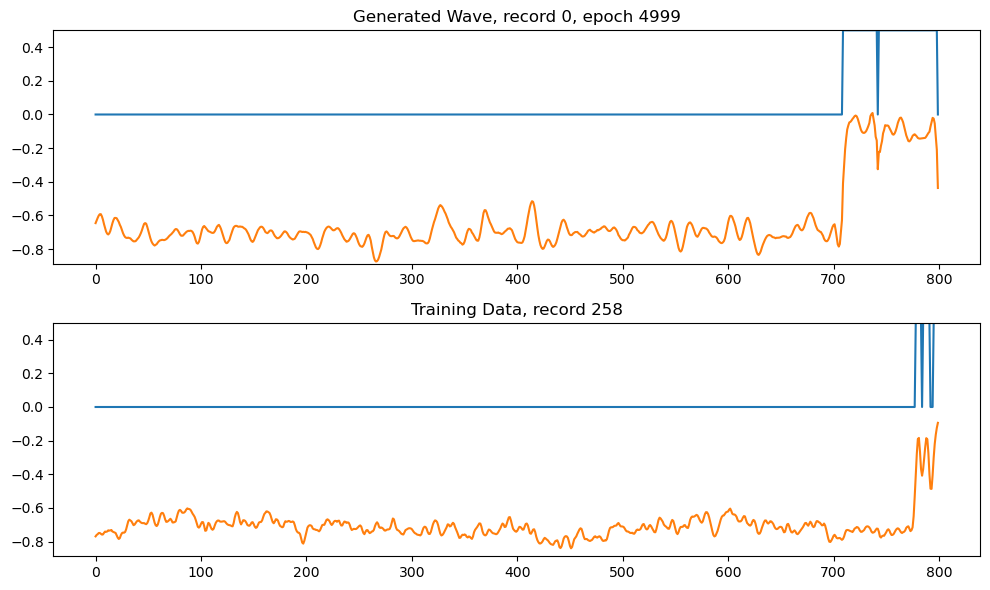

In [37]:
#checkpoint.restore('noiseCheckpoints/checkpoint-130').assert_existing_objects_matched()
 
writeNow=False 

epochs=5000

train(training_dataset, epochs)

In [38]:
def check_event_locations(data):
    """Check where events occur in each record"""
    for i in range(min(5, len(data))):  # Check first 5 records
        record = data[i, :, 0]
        
        # Find where changes occur
        diffs = tf.abs(record[1:] - record[:-1])
        change_indices = tf.where(diffs > 1e-6)
        
        if len(change_indices) > 0:
            print(f"\nRecord {i}: Changes at positions {change_indices.numpy().flatten()}")
            print(f"  In buffer region (0-100): {any(idx < buffer for idx in change_indices.numpy().flatten())}")
            print(f"  In display region (100-400): {any(buffer <= idx < crop for idx in change_indices.numpy().flatten())}")
            print(f"  In end buffer (400-500): {any(idx >= crop for idx in change_indices.numpy().flatten())}")
        else:
            print(f"\nRecord {i}: No changes detected")

# Call it after throw_unchanged
check_event_locations(training_data)


Record 0: Changes at positions [716]
  In buffer region (0-100): False
  In display region (100-400): True
  In end buffer (400-500): False

Record 1: Changes at positions [281 290 367 595 604]
  In buffer region (0-100): False
  In display region (100-400): True
  In end buffer (400-500): False

Record 2: Changes at positions [60 88]
  In buffer region (0-100): True
  In display region (100-400): False
  In end buffer (400-500): False

Record 3: Changes at positions [240 244]
  In buffer region (0-100): False
  In display region (100-400): True
  In end buffer (400-500): False

Record 4: Changes at positions [920 937]
  In buffer region (0-100): False
  In display region (100-400): False
  In end buffer (400-500): True


In [ ]:
checkpoint.restore('noiseCheckpoints/checkpoint-273').assert_existing_objects_matched()


In [39]:
for i in range(50):
    writeMe(training_dataset,samples=1000,  file=f"2024_06_17_OUTPUT/2024_06_17_noise_{i}.parquet", batch_size=100)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.28s/it]


Data saved to 2024_06_17_OUTPUT/2024_06_17_noise_0.parquet - Total records: 335947


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:38<00:00,  3.83s/it]


Data saved to 2024_06_17_OUTPUT/2024_06_17_noise_1.parquet - Total records: 306087


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:00<00:00,  6.08s/it]


...

Data saved to 2024_06_17_OUTPUT/2024_06_17_noise_6.parquet - Total records: 257015


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:27<00:00,  2.76s/it]


Data saved to 2024_06_17_OUTPUT/2024_06_17_noise_7.parquet - Total records: 320327


 70%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                             | 7/10 [00:41<00:17,  5.91s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import time

def ensure_sequential_continuity(generated_data, raw_tolerance=0.05, debug=True):
    valid_sequences = [generated_data[0]]
    
    for i in range(1, len(generated_data)):
        current_seq = generated_data[i]
        prev_seq = valid_sequences[-1]
        
        
        raw_match = np.isclose(current_seq[0, 1], prev_seq[-1, 1], 
                              rtol=0, atol=raw_tolerance)
        value_match = current_seq[0, 0] == prev_seq[-1, 0]
        
        if raw_match and value_match:
            valid_sequences.append(current_seq)
            
        if i < 5 and debug:  # Debug first few
            print(f"\nSequence {i}:")
            print(f"Raw: prev end = {prev_seq[-1,1]:.5f}, current start = {current_seq[0,1]:.5f}")
            print(f"Value: prev end = {prev_seq[-1,0]:.5f}, current start = {current_seq[0,0]:.5f}")
            print(f"Matches: time={raw_match}, value={value_match}")
    
    valid_sequences = np.array(valid_sequences)
    print(f"\nKept {len(valid_sequences)} sequences out of {len(generated_data)} ({len(valid_sequences)/len(generated_data)*100:.1f}%)")
    
    return valid_sequences

def generate_and_save_records(total_rows_needed=5_000_000,
                            batch_size=5_000,
                            sample_rate=0.01,
                            output_dir="generated_data",
                            mb_per_file=25,
                            file_start_No=0):
    
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    rows_generated = 0
    valid_data = []
    file_counter = 1
    
    # Calculate roughly how many rows fit in 10MB
    # Each row is 3 values, 1 integer and two 8 byte float64s
    rows_per_file = int((mb_per_file * 1024 * 1024) / ( 2 + (2 * 8) ))
    
    print(f"Aiming for ~{rows_per_file:,} rows/points per file")
    
    while rows_generated < total_rows_needed:
        print(f"\nGenerating batch {rows_generated//batch_size + 1}...")
        fake_iter = iter(large_fake_dataset)
        # Generate one batch
        start_time = time.time()
        fake_batch = next(fake_iter)
        generated_noise = generator(fake_batch[:,:,1:2], training=False)
        noised = tf.concat([fake_batch[:,:,0:1], generated_noise], axis=-1)[:,buffer:-buffer,:]
 
        
        # Validate sequential continuity
        if rows_generated < 1:
            valid_batch = ensure_sequential_continuity(noised, debug=True)
        else:
            valid_batch = ensure_sequential_continuity(noised, debug=False)
        #recall your minmax scaler above?
        valid_batch = valid_batch.reshape(-1, 2)
        
        # Unscale the data before adding to our collection
        valid_batch = scaler.inverse_transform(valid_batch)
        # Reshape from (n, 800, 2) to (n*800, 2) HAVEN't WE ALREADY?
        # valid_batch = valid_batch.reshape(-1, 2)
        
        # Add to our collection
        valid_data.append(valid_batch)
        rows_generated += len(valid_batch)
        clear_output(wait=True)
        print(f"\nGenerating batch {rows_generated//batch_size + 1}...")      
        print(f"Generated in {time.time() - start_time:.1f}s")
        print(f"Total valid rows so far: {rows_generated:,}")
        
        # Check if we have enough for a file
        while len(np.concatenate(valid_data*800)) >= rows_per_file:
            # Combine all our data
            all_data = np.concatenate(valid_data)
            
            # Take enough for one file
            file_data = all_data[:rows_per_file]
            
            # Keep the remainder for the next file
            valid_data = [all_data[rows_per_file:]]
            
            # Convert to DataFrame and save
            df = pd.DataFrame(file_data, columns=['Channels', 'Noisy Current'])
            df['Time'] = np.arange(len(df)) * sample_rate
            filename = f"{output_dir}/generated_data_{file_start_No + file_counter:04d}.parquet"
            df.to_parquet(filename)
            
            file_size_mb = Path(filename).stat().st_size / (1024 * 1024)
            print(f"Saved {filename} ({file_size_mb:.1f}MB)")
            
            file_counter += 1
    
    # Save any remaining data
    if valid_data:
        remaining_data = np.concatenate(valid_data)
        if len(remaining_data) > 0:
            df = pd.DataFrame(remaining_data, columns=['time', 'value'])
            filename = f"{output_dir}/generated_data_{file_counter:04d}.parquet"
            df.to_parquet(filename)
            file_size_mb = Path(filename).stat().st_size / (1024 * 1024)
            print(f"Saved final file {filename} ({file_size_mb:.1f}MB)")
    
    print("\nGeneration complete!")
    print(f"Total rows generated: {rows_generated:,}")
    print(f"Total files created: {file_counter}")



In [ ]:
print(batch_size)
old_batch=batch_size
batch_size = 10_000
#Go for it with pure generation
large_fake_dataset = create_dataset(fake_data, batch_size)
print(batch_size)
fake_iter = iter(large_fake_dataset)
fake_batch = next(fake_iter)
generated_noise = generator(fake_batch[:,:,1:2], training=False)
noised = tf.concat([fake_batch[:,:,0:1], generated_noise], axis=-1)
print(noised.shape)
batch_size=old_batch
print(batch_size)

In [ ]:
#Concern here is that consecutive records have exact same float value sometimes which is improbable 
old_batch=batch_size
batch_size = 10_000
large_fake_dataset = create_dataset(fake_data, batch_size)
generate_and_save_records(
    total_rows_needed=100_000_000,  
    batch_size=batch_size,  # Adjust based on your GPU memory
    output_dir="generated_data",
    mb_per_file=25,
    file_start_No=0
)
batch_size=100
